In [11]:
using Flight
using ControlSystems, RobustAndOptimalControl, Plots

includet("sbr.jl"); using .SelfBalancingRobot

In [ ]:
mdl = SelfBalancingRobot.Vehicle() |> Model
lss = linearize(mdl)
nss = named_ss(lss)
P_m = nss

NamedStateSpace{Continuous, Float64}
A = 
 -2.3042245534448544  46.08449106889709   50.46518216614687    0.0
  0.4018996314148001  -8.037992628296003  -1.9602178196767788  0.0
  1.0                  0.0                 0.0                 0.0
  0.0                  1.0                 0.0                 0.0
B = 
 -39.01332577261129
   6.804649844060108
   0.0
   0.0
C = 
 1.0                    0.0                0.0                  0.0
 0.0                    1.0                0.0                  0.0
 0.0                    0.0                1.0                  0.0
 0.0                    0.0                0.0                  1.0
 0.004420895945562803  -0.088417918911256  0.12553735398355542  0.0
D = 
 0.0
 0.0
 0.0
 0.0
 0.07485114828466116

Continuous-time state-space model
With state  names: ω v θ η
     input  names: motor
     output names: ω v θ η τ_m


In [ ]:
dampreport(P_m)

|        Pole        |   Damping     |   Frequency   |   Frequency   | Time Constant |
|                    |    Ratio      |   (rad/sec)   |     (Hz)      |     (sec)     |
+--------------------+---------------+---------------+---------------+---------------+
| +0                 |  -1           |  0            |  0            |  -Inf         |
| -4.14              |  1            |  4.14         |  0.659        |  0.241        |
| +6.16              |  -1           |  6.16         |  0.98         |  -0.162       |
| -12.4              |  1            |  12.4         |  1.97         |  0.0809       |


In [ ]:
P_m2ω = P_m[:ω, :motor]

NamedStateSpace{Continuous, Float64}
A = 
 -2.3042245534448544  46.08449106889709   50.46518216614687    0.0
  0.4018996314148001  -8.037992628296003  -1.9602178196767788  0.0
  1.0                  0.0                 0.0                 0.0
  0.0                  1.0                 0.0                 0.0
B = 
 -39.01332577261129
   6.804649844060108
   0.0
   0.0
C = 
 0.0  1.0  0.0  0.0
D = 
 0.0

Continuous-time state-space model
With state  names: ω v θ η
     input  names: motor
     output names: v


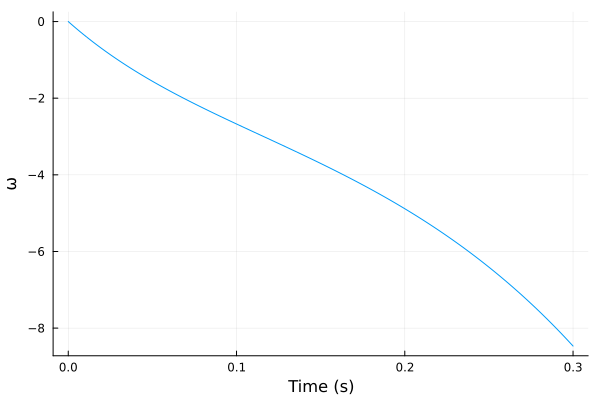

In [ ]:
step(P_m2ω, 0.3) |> plot

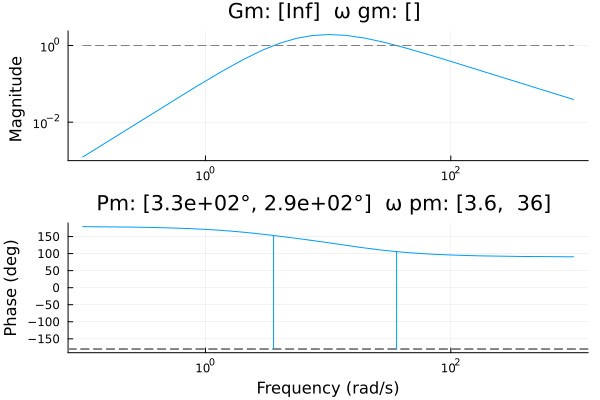

In [34]:
marginplot(P_m2ω)

|        Pole        |   Damping     |   Frequency   |   Frequency   | Time Constant |
|                    |    Ratio      |   (rad/sec)   |     (Hz)      |     (sec)     |
+--------------------+---------------+---------------+---------------+---------------+
| +0                 |  -1           |  0            |  0            |  -Inf         |
| -2.6               |  1            |  2.6          |  0.414        |  0.385        |
| +3.89              |  -1           |  3.89         |  0.62         |  -0.257       |
| -31.1              |  1            |  31.1         |  4.96         |  0.0321       |


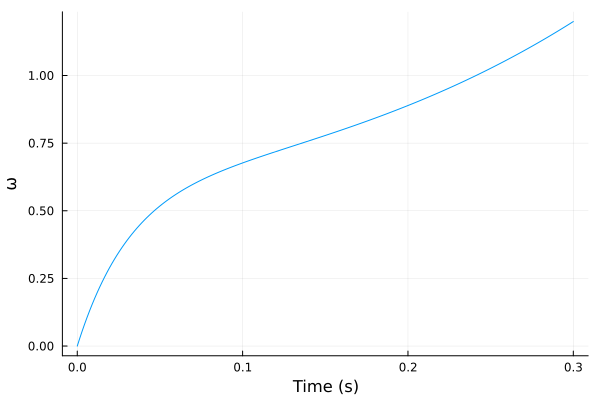

In [96]:
#define controller in series with the plant as a simple gain plus a sign
#inversion
K_ω2m = 0.5
C_ω2m = named_ss(ss(-1 * K_ω2m), C_ω2m; u = :ω_err, y = :motor)

#open loop transfer function
L_ω2m = series(C_ω2m, P_m2ω)

#closed loop transfer function
T_ω2m = output_comp_sensitivity(P_m2ω, C_ω2m)

#command to control input transfer function
CS_ω2m = G_CS(P_m2ω, C_ω2m)

dampreport(T_ω2m)

step(T_ω2m, 0.3) |> plot


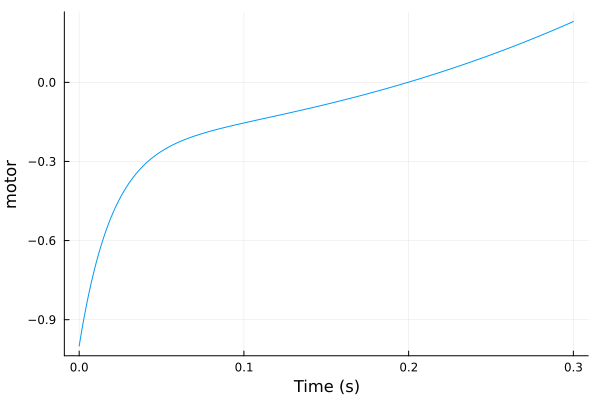

In [89]:
step(CS_ω2m, 0.3) |> plot

Next: Apply the $\omega$ feedback to the open-loop MIMO plant P_m to obtain P_omega, then add an outer
$\theta$ loop.